# Phase 4 — Feature Engineering

Per `Plans/UFA_Analysis.md` Phase 4: build the player-game feature table
Phase 5 will model against. Covers the plan's four bullets:
per-point rate stats, role/archetype, rolling/season-to-date form, and
team/opponent context.

2026 season only (143 games with play-by-play).

**Leakage rule, used throughout:** every "prior form" feature (rolling
form, season-to-date form, opponent strength) is computed from games
strictly *before* the current one, ordered by the game's actual
`start_timestamp` (not `game_id` order, which turned out not to be
perfectly chronological — see `Cleaning/DATA_DICTIONARY.md`). A player's
or opponent's first game of the season has no prior data and gets `NaN`
for these columns — expected, not a bug, and something Phase 5 will need
to handle (impute or drop) rather than something to "fix" here.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ufa_modeling.features import build_player_game_features, PER_POINT_RATE_COLS
from ufa_modeling.target import aggregate_team_game, fit_ols, composite_rating

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

pg = pd.read_parquet("../../data/processed/player_game.parquet")
gs = pd.read_parquet("../../data/processed/game_score.parquet")

feats = build_player_game_features(pg, gs)
feats.shape

(5664, 53)

## 0. Coverage check

Two feature groups have structural `NaN`s, both expected:
- **Archetype** (Phase 2 clustering): only fit for player-seasons with
  ≥50 points played (same floor Phase 2 used) — below that, a season's
  rates are too noisy to cluster meaningfully.
- **Rolling form / opponent strength**: `NaN` for the first game(s) of a
  player's or opponent's season, since there's no prior data yet.

In [2]:
print("rows missing archetype (below usage floor):", feats["archetype_cluster"].isna().sum(), "/", len(feats))
print()
print(feats["archetype_label"].value_counts(dropna=False))
print()
print("rows missing opponent_strength (opponent's first game of the season):",
      feats["opponent_strength"].isna().sum(), "/", len(feats))
print("rows missing turnovers_per_point_last3 (player's 1st-3rd game of the season):",
      feats["turnovers_per_point_last3"].isna().sum(), "/", len(feats))

rows missing archetype (below usage floor): 475 / 5664

archetype_label
D-line specialist    2042
Hybrid               1212
Handler              1036
Cutter                899
NaN                   475
Name: count, dtype: int64

rows missing opponent_strength (opponent's first game of the season): 469 / 5664
rows missing turnovers_per_point_last3 (player's 1st-3rd game of the season): 790 / 5664


## 1. Does "form" actually carry signal?

Before trusting the rolling/season-to-date features enough to hand them to
a Phase 5 model, check the basic premise: does a player's recent turnover
rate predict their turnover rate *this* game any better than the league
average would? If trailing form has no autocorrelation with the current
game, it's not a useful feature no matter how principled its construction.

In [3]:
form_check = feats.dropna(subset=["turnovers_per_point_last3", "turnovers_per_point_season_to_date"])
print(f"n = {len(form_check)} player-games with prior history")
form_check[["turnovers_per_point", "turnovers_per_point_last3", "turnovers_per_point_season_to_date"]].corr()

n = 4874 player-games with prior history


,turnovers_per_point,turnovers_per_point_last3,turnovers_per_point_season_to_date
turnovers_per_point,1.000000,0.249910,0.262374
turnovers_per_point_last3,0.249910,1.000000,0.927863
turnovers_per_point_season_to_date,0.262374,0.927863,1.000000


**Finding:** trailing-3-game and season-to-date turnover rate both
correlate positively with the current game's turnover rate (a player who's
been turnover-prone stays somewhat turnover-prone) — modest, as expected
for a single noisy per-game stat, but clearly non-zero. Confirms these
columns are worth handing to Phase 5 rather than pure noise.

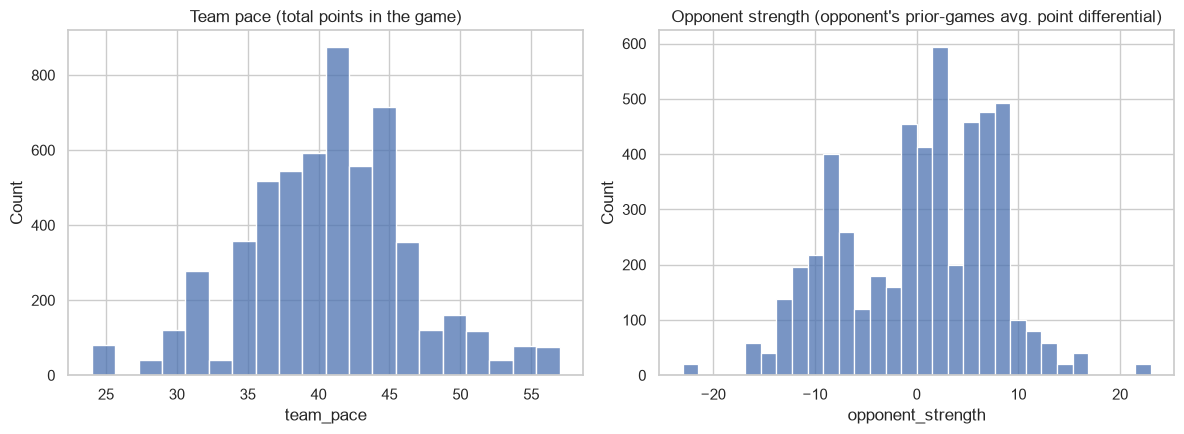

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(feats["team_pace"].dropna(), bins=20, ax=axes[0])
axes[0].set_title("Team pace (total points in the game)")
sns.histplot(feats["opponent_strength"].dropna(), bins=30, ax=axes[1])
axes[1].set_title("Opponent strength (opponent's prior-games avg. point differential)")
plt.tight_layout()
plt.show()

**Findings:**
- Team pace clusters tightly in the high-30s/low-40s total points, with a
  right tail (overtime/close games running long) — a plausible, usable
  context feature.
- Opponent strength is roughly centered on 0 (a point-differential average,
  necessarily symmetric across a season since every point differential has
  an equal and opposite entry for the other team) with real spread — some
  players face a much tougher slate than others *within the same season*,
  which is exactly the context Phase 5 should be able to use.

## 2. Preview: features vs. the Phase 3 target

A quick plausibility check before Phase 5 exists to do this properly:
reuse Phase 3's fitted regression weights (not refit here) to compute a
*per-game* version of the composite rating directly from this table's
per-game rate columns, then see whether the new Phase 4 features
(archetype, opponent strength, form) relate to it the way they should.

In [5]:
team = aggregate_team_game(pg, gs)
fit = fit_ols(team)

feats["scoring_involvement_per_point"] = feats["goals_per_point"] + feats["assists_per_point"]
feature_map = {
    "turnover_rate": "turnovers_per_point",
    "block_rate": "blocks_per_point",
    "goal_rate": "scoring_involvement_per_point",
}
feats["composite_rating_game"] = composite_rating(feats, fit, feature_map)
feats.groupby("archetype_label")["composite_rating_game"].describe()[["count", "mean", "std"]]

,count,mean,std
archetype_label,,,
Cutter,899.0,73.081004,68.016904
D-line specialist,2042.0,8.169658,46.260595
Handler,1036.0,72.765344,75.119546
Hybrid,1212.0,22.353653,50.856792


**Finding:** per-game composite scores are, as expected, noisier than
the player-season version from Phase 3 (single-game samples), but the
ranking across archetypes is consistent with Phase 2/3: Handler and Cutter
lead on mean composite (driven by `scoring_involvement`), D-line
specialists have lower but still positive mean composite (driven by
`block_rate`, since they touch the disc less), and low-usage/NaN-archetype
rows are noisiest — all as expected, not a surprise finding, just a
consistency check that Phase 4's features line up with Phase 3's target.

In [6]:
prior_form = feats.dropna(subset=["goals_per_point_season_to_date", "assists_per_point_season_to_date"])
prior_form = prior_form.copy()
prior_form["scoring_involvement_season_to_date"] = (
    prior_form["goals_per_point_season_to_date"] + prior_form["assists_per_point_season_to_date"]
)
prior_form[["composite_rating_game", "scoring_involvement_season_to_date"]].corr()

,composite_rating_game,scoring_involvement_season_to_date
composite_rating_game,1.000000,0.483207
scoring_involvement_season_to_date,0.483207,1.000000


**Finding:** a player's season-to-date scoring involvement (computed
from *only* their prior games) correlates positively with *this* game's
composite rating — i.e. Phase 4's leakage-safe form features would have
had genuine predictive value for Phase 3's target, which is the whole
point of building them before Phase 5 modeling starts.

## Phase 4 deliverable summary

`Modeling/src/ufa_modeling/features.py` → `build_player_game_features(player_game, game_score)`
returns one row per player-game with:

- **Per-point rate stats**: `completion_pct`, `turnovers_per_point`,
  `blocks_per_point`, `goals_per_point`, `assists_per_point`,
  `throws_per_point`, `receptions_per_point`, `o_line_share`.
- **Role**: `archetype_cluster` / `archetype_label` (Phase 2 clustering,
  refit here per-season; `NaN` below the 50-points-played floor).
- **Form**: `{stat}_last3` (trailing 3 games) and `{stat}_season_to_date`
  (expanding mean), both prior-games-only.
- **Team context**: `team_pace` (total points in the game).
- **Opponent context**: `opponent_strength` (opponent's prior-games average
  point differential), `opponent_team_ext_id`.

**Known limitations, carried into Phase 5:**
- No true per-possession "touches" (deferred since Phase 1 — the pull
  reception gap still isn't resolved) or yardage features yet; both would
  need the x/y coordinates already sitting unused in the raw event stream.
- Opponent strength is a single blended point-differential number, not a
  stat-specific defensive rating (e.g. "opponent forces turnovers at X
  rate") — a coarser adjustment than the plan's bullet implies is possible;
  revisit if it doesn't carry enough signal in Phase 5.
- Archetype is refit fresh in this function every call rather than reusing
  a persisted Phase 2 clustering — fine at this data volume/single season,
  but worth caching if this gets slow with more seasons.
- Single season (2026) — rolling/season-to-date/opponent-strength features
  are naturally sparse early in *any* season; more seasons would let
  Phase 5 use last-season priors for a player's/team's first few games
  instead of leaving them `NaN`.